In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("bts.csv")
df.head()

,id,album_title,eng_album_title,album_rd,album_seq,track_title,raw_track_title,eng_track_title,lyrics,hidden_track,...,spotify_track_mode,spotify_track_speechiness,spotify_track_acousticness,spotify_track_instrumentalness,spotify_track_liveness,spotify_track_valence,spotify_track_tempo,spotify_track_time_signature,eng_lyrics_source_url,eng_lyrics_credits
0,BTS-1,2 Cool 4 Skool,2 Cool 4 Skool,2013-06-12,1,Intro: 2 Cool 4 Skool (ft. DJ Friz),NaN,Intro: 2 Cool 4 Skool (ft. DJ Friz),we're now going to progress to some steps\nwhi...,False,...,1.0,0.245,0.1790,0.266000,0.179,0.532,94.871,4.0,NaN,NaN
1,BTS-2,2 Cool 4 Skool,2 Cool 4 Skool,2013-06-12,2,We Are Bulletproof Pt.2,NaN,We Are Bulletproof Pt.2,(what) give it to me\n (what) be nervous\n (wh...,False,...,0.0,0.160,0.0104,0.000006,0.134,0.868,144.020,4.0,NaN,NaN
2,BTS-3,2 Cool 4 Skool,2 Cool 4 Skool,2013-06-12,3,Skit: Circle Room Talk,NaN,Skit: Circle Room Talk,rap monster: it was a big hit\nv: year 2006!\n...,False,...,1.0,0.802,0.9120,0.000000,0.913,0.817,121.045,3.0,NaN,NaN
3,BTS-4,2 Cool 4 Skool,2 Cool 4 Skool,2013-06-12,4,No More Dream,NaN,No More Dream,"hey, what's your dream?\n hey, what's your dre...",False,...,1.0,0.470,0.0118,0.000002,0.431,0.594,167.898,4.0,NaN,NaN
4,BTS-5,2 Cool 4 Skool,2 Cool 4 Skool,2013-06-12,5,Interlude,NaN,Interlude,NaN,False,...,0.0,0.319,0.4940,0.762000,0.392,0.854,125.897,4.0,NaN,NaN


In [5]:
df.shape

(444, 34)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              444 non-null    str    
 1   album_title                     444 non-null    str    
 2   eng_album_title                 444 non-null    str    
 3   album_rd                        444 non-null    str    
 4   album_seq                       444 non-null    int64  
 5   track_title                     444 non-null    str    
 6   raw_track_title                 94 non-null     str    
 7   eng_track_title                 443 non-null    str    
 8   lyrics                          389 non-null    str    
 9   hidden_track                    444 non-null    bool   
 10  remix                           444 non-null    bool   
 11  featured                        22 non-null     str    
 12  performed_by                    421 non-null   

In [7]:
df.isnull().sum()

id                                  0
album_title                         0
eng_album_title                     0
album_rd                            0
album_seq                           0
track_title                         0
raw_track_title                   350
eng_track_title                     1
lyrics                             55
hidden_track                        0
remix                               0
featured                          422
performed_by                       23
repackaged                          0
lang                               22
has_full_ver                        0
is_alt_lang_ver                     0
spotify_album_id                   23
spotify_track_duration_ms          23
spotify_track_id                   23
spotify_track_danceability         23
spotify_track_energy               23
spotify_track_key                  23
spotify_track_loudness             23
spotify_track_mode                 23
spotify_track_speechiness          23
spotify_trac

In [8]:
df['featured'] = df['featured'].fillna('None')
df['lyrics'] = df['lyrics'].fillna('No Lyrics Available')
df['lang'] = df['lang'].fillna('Unknown')


df['featured'].isnull().sum()

np.int64(0)

In [9]:
num_cols = ['spotify_track_duration_ms', 'spotify_track_danceability']

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


df[['featured', 'lyrics', 'spotify_track_danceability']].isnull().sum()

featured                      0
lyrics                        0
spotify_track_danceability    0
dtype: int64

In [10]:
album_counts = df['album_title'].value_counts()
print("Top 5 BTS Albums by Track Count:")
print(album_counts.head(5))

Top 5 BTS Albums by Track Count:
album_title
Proof                                                    48
LOVE YOURSELF 結 'Answer'                                 26
화양연화 The Most Beautiful Moment In Life: Young Forever    23
BTS THE BEST                                             22
PERMISSION TO DANCE ON STAGE - LIVE                      22
Name: count, dtype: int64


In [11]:
import warnings
warnings.filterwarnings('ignore')

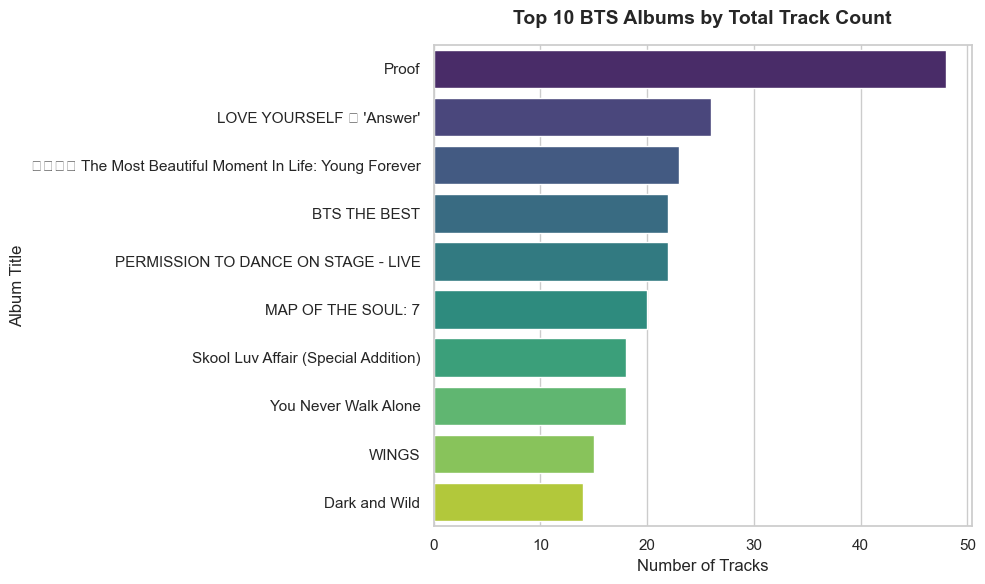

In [12]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


top_10_albums = df['album_title'].value_counts().head(10)


sns.barplot(x=top_10_albums.values, y=top_10_albums.index, hue=top_10_albums.index, palette="viridis", legend=False)


plt.title('Top 10 BTS Albums by Total Track Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Tracks', fontsize=12)
plt.ylabel('Album Title', fontsize=12)
plt.tight_layout()


plt.show()

In [13]:
initial_dupes = df.duplicated().sum()
print(f"Initial duplicate rows found: {initial_dupes}")


df = df.drop_duplicates()


print(f"Final duplicate rows remaining: {df.duplicated().sum()}")

Initial duplicate rows found: 0
Final duplicate rows remaining: 0


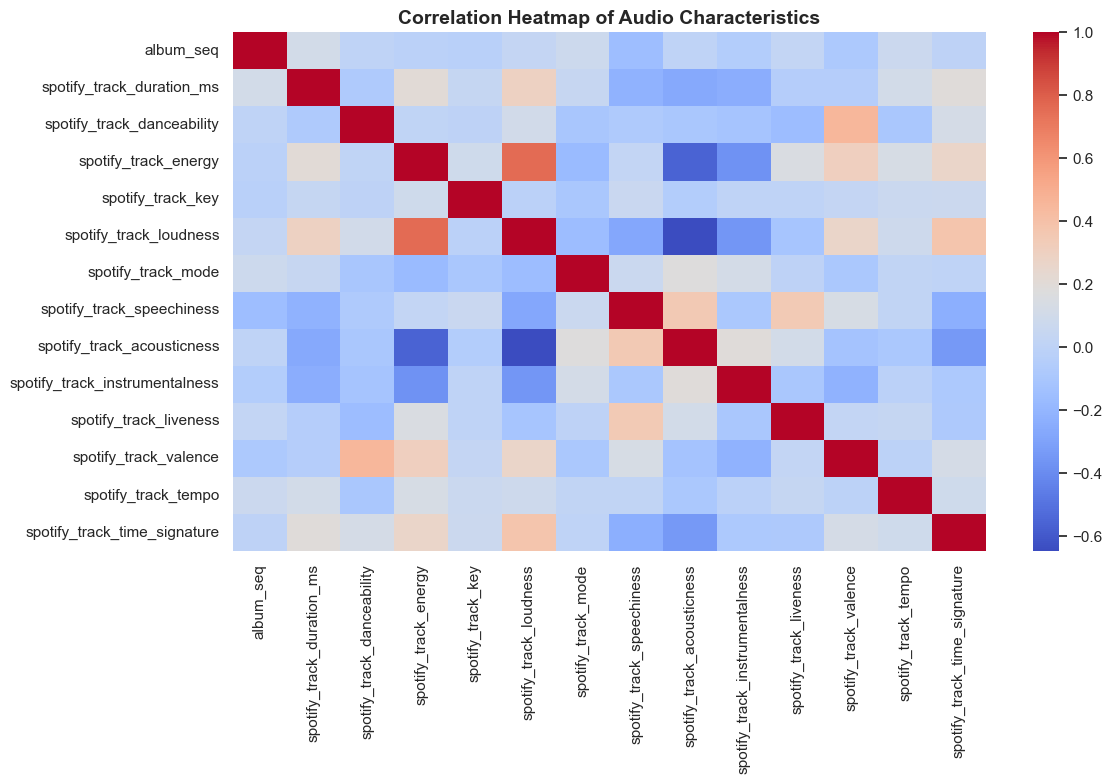

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Audio Characteristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
df.to_csv("cleaned_dataset.csv", index=False)
print("cleaned_dataset.csv has been successfully exported!")

cleaned_dataset.csv has been successfully exported!




1.**High Correlation & Multi-collinearity:** Our correlation heatmap helps identify features that change tightly together, which can disrupt certain ML algorithms.
   
2. **Statistical Outliers:** Columns like track duration and extreme loudness values show localized variance that may need capping or trimming prior to scaling.
   
3. **Definitive Structural Changes:** We successfully eliminated all empty rows, dropped duplicate records, and imputed missing text/numerical gaps with medians and static placeholders to guarantee `.fit()` runs smoothly without crashing.l